In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_SDB_EL_Substation"
start_forecast_date = pd.to_datetime("2026-04-20").date()

prediction_files = sorted(pred_dir.glob(f"*{target_col}*profile_predictions.csv"))

print("Candidate files found:", len(prediction_files))


def detect_model_name(file_name):
    name = file_name.lower()

    if "random_forest" in name:
        return "random_forest"
    if "xgboost" in name:
        return "xgboost"
    if "catboost" in name:
        return "catboost"
    if "ridge" in name:
        return "ridge"
    if "linear_regression" in name:
        return "linear_regression"

    return "unknown"


def detect_resolution_from_horizons(n_horizons):
    if n_horizons == 96:
        return "15min", 0.25, 23, 45
    if n_horizons == 48:
        return "30min", 0.5, 23, 30
    if n_horizons == 24:
        return "60min", 1.0, 23, 0

    return "unknown", np.nan, None, None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def sort_horizon_columns(cols):
    """
    Sort horizon columns by number, not alphabetically.
    This prevents wrong order like 1, 10, 11, ..., 2, 20.
    """
    def horizon_number(col):
        # examples:
        # y_tplus_001_true
        # y_tplus_1_true
        parts = col.replace("_true", "").replace("_pred", "").split("_")
        nums = [p for p in parts if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)

Candidate files found: 69


In [2]:
rows = []
kept_files = []
skipped_files = []
bad_profile_rows = []

for file in prediction_files:
    model_name = detect_model_name(file.name)

    if model_name == "unknown":
        skipped_files.append((file.name, "unknown model name"))
        continue

    df = pd.read_csv(file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    if len(true_cols) == 0:
        skipped_files.append((file.name, "no true columns"))
        continue

    missing_pred_cols = [c for c in pred_cols if c not in df.columns]
    if missing_pred_cols:
        skipped_files.append((file.name, "missing pred columns"))
        continue

    n_horizons = len(true_cols)
    resolution, dt_hours, expected_issue_hour, expected_issue_minute = detect_resolution_from_horizons(n_horizons)

    if resolution == "unknown":
        skipped_files.append((file.name, f"unknown horizon count: {n_horizons}"))
        continue

    # Keep only correct issue time for that resolution
    issue_time_ok = (
        (df["issue_time"].dt.hour == expected_issue_hour) &
        (df["issue_time"].dt.minute == expected_issue_minute)
    )

    df = df[issue_time_ok].copy()

    if df.empty:
        skipped_files.append((file.name, f"wrong issue time for {resolution}"))
        continue

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    # Keep only forecast dates from 2026-04-20 onward
    df = df[df["forecast_date"] >= start_forecast_date].copy()

    if df.empty:
        skipped_files.append((file.name, "no forecast dates after start date"))
        continue

    # ------------------------------------------------------
    # Row-level quality filtering
    # ------------------------------------------------------
    good_rows = []

    for idx, r in df.iterrows():
        y_true_row = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred_row = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        valid = ~(np.isnan(y_true_row) | np.isnan(y_pred_row))

        # Require full horizon to be valid
        if valid.sum() != n_horizons:
            bad_profile_rows.append((file.name, r["forecast_date"], "incomplete horizon"))
            continue

        # Optional sanity check:
        # For this Tech Room load, a completely flat daily actual profile is suspicious.
        # This removes bad 60min runs that do not capture the daily operating pattern.
        actual_range = np.nanmax(y_true_row) - np.nanmin(y_true_row)
        actual_mean = np.nanmean(y_true_row)

        if actual_mean != 0:
            actual_range_ratio = actual_range / abs(actual_mean)
        else:
            actual_range_ratio = np.nan

        # If the day is almost flat, skip that row.
        # You can lower/raise 0.05 depending on your data.
        if actual_range_ratio < 0.05:
            bad_profile_rows.append((file.name, r["forecast_date"], "suspicious flat actual profile"))
            continue

        good_rows.append(idx)

    df_good = df.loc[good_rows].copy()

    if df_good.empty:
        skipped_files.append((file.name, "all rows failed quality filters"))
        continue

    y_true = df_good[true_cols].to_numpy(dtype=float).ravel()
    y_pred = df_good[pred_cols].to_numpy(dtype=float).ravel()

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        skipped_files.append((file.name, "no valid values after filtering"))
        continue

    errors = y_true - y_pred

    kept_files.append(file.name)

    rows.append({
        "file_name": file.name,
        "model_name": model_name,
        "target_col": target_col,
        "resolution": resolution,
        "dt_hours": dt_hours,

        "first_forecast_date": df_good["forecast_date"].min(),
        "last_forecast_date": df_good["forecast_date"].max(),
        "n_forecast_days": df_good["forecast_date"].nunique(),
        "n_issue_times": len(df_good),

        "n_horizon_steps": n_horizons,
        "n_values": len(y_true),

        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),

        "bias_actual_minus_pred": np.mean(errors),
        "error_std": np.std(errors),
    })


error_summary = pd.DataFrame(rows)

if not error_summary.empty:
    error_summary = error_summary.sort_values(
        ["resolution", "MAE"]
    ).reset_index(drop=True)

print("Files kept:", len(kept_files))
print("Files skipped:", len(skipped_files))
print("Bad profile rows:", len(bad_profile_rows))

display(error_summary)

Files kept: 32
Files skipped: 37
Bad profile rows: 0


,file_name,model_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,run_20260528_115442_63c0a563_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-21,2026-04-30,10,10,96,960,0.620521,0.790645,21.490573,0.634994,-0.141946,0.777799
1,run_20260521_103701_6aa7d6e5_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.621010,0.791210,21.650029,0.639420,-0.137269,0.779212
2,run_20260521_103436_8efce381_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.649633,0.830202,23.097239,0.603004,-0.177335,0.811041
3,run_20260528_115248_6555fdd3_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-21,2026-04-30,10,10,96,960,0.655656,0.838039,23.141396,0.589923,-0.191637,0.815833
4,run_20260528_115551_310b7ffb_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-21,2026-04-30,10,10,96,960,0.656166,0.820475,23.547422,0.606932,-0.141139,0.808245
5,run_20260521_103809_33852bc0_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.666073,0.831078,24.148539,0.602166,-0.136107,0.819857
6,run_20260528_115247_e5788bbd_ridge_BU_TotActPw...,ridge,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-21,2026-04-30,10,10,96,960,0.683250,0.873350,24.144405,0.554637,-0.172495,0.856146
7,run_20260521_103435_00fafa11_ridge_BU_TotActPw...,ridge,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.696402,0.890195,24.824403,0.543555,-0.192188,0.869201
8,run_20260521_103554_7349fd9e_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,0.724003,0.911603,26.625644,0.521337,-0.299391,0.861037
9,run_20260528_115357_a9278b63_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,2026-04-21,2026-04-30,10,10,96,960,0.726324,0.918743,26.559487,0.507138,-0.318350,0.861825


In [3]:
skipped_files_df = pd.DataFrame(
    skipped_files,
    columns=["file_name", "reason"]
)

display(skipped_files_df)

,file_name,reason
0,run_20260410_134530_8dfa5d88_ridge_BU_TotActPw...,no forecast dates after start date
1,run_20260410_134531_7864d386_random_forest_BU_...,no forecast dates after start date
2,run_20260410_134815_9105d839_xgboost_BU_TotAct...,no forecast dates after start date
3,run_20260410_142221_c2af3d23_hist_gbr_BU_TotAc...,unknown model name
4,run_20260410_142307_593fff23_xgboost_BU_TotAct...,no forecast dates after start date
5,run_20260410_142802_ccf3917b_hist_gbr_BU_TotAc...,unknown model name
6,run_20260410_142846_65a25c4b_xgboost_BU_TotAct...,no forecast dates after start date
7,run_20260410_144423_c92bb7af_ridge_BU_TotActPw...,no forecast dates after start date
8,run_20260410_144424_a18410db_random_forest_BU_...,no forecast dates after start date
9,run_20260410_144653_ffd2ece1_xgboost_BU_TotAct...,no forecast dates after start date


In [4]:
bad_profile_rows_df = pd.DataFrame(
    bad_profile_rows,
    columns=["file_name", "forecast_date", "reason"]
)

display(bad_profile_rows_df)

,file_name,forecast_date,reason


In [5]:
best_60min = (
    error_summary[error_summary["resolution"] == "60min"]
    .sort_values("MAE")
    .iloc[0]
)

display(best_60min)

file_name                 run_20260513_095636_ab78adf8_catboost_BU_TotAc...
model_name                                                         catboost
target_col                                   BU_TotActPwr_SDB_EL_Substation
resolution                                                            60min
dt_hours                                                                1.0
first_forecast_date                                              2026-04-23
last_forecast_date                                               2026-04-30
n_forecast_days                                                           8
n_issue_times                                                             8
n_horizon_steps                                                          24
n_values                                                                192
MAE                                                                0.443163
RMSE                                                               0.560371
MAPE_%      

In [6]:
best_per_model = (
    error_summary
    .sort_values("MAE")
    .groupby("model_name", as_index=False)
    .first()
)

display(best_per_model)

,model_name,file_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,2026-04-23,2026-04-30,8,8,24,192,0.443163,0.560371,15.624057,0.807232,-0.179620,0.530803
1,random_forest,run_20260527_084222_5e6d968c_random_forest_BU_...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,2026-04-22,2026-04-30,9,9,24,216,0.536657,0.675144,18.665194,0.709082,-0.303430,0.603116
2,ridge,run_20260527_083211_c3cb7819_ridge_BU_TotActPw...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,2026-04-22,2026-04-30,9,9,24,216,0.519317,0.676752,18.218909,0.707694,-0.229092,0.636797
3,xgboost,run_20260513_095611_c051fb77_xgboost_BU_TotAct...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,2026-04-23,2026-04-30,8,8,24,192,0.463997,0.607157,15.658446,0.773700,-0.032042,0.606311


In [7]:
def calculate_energy_error_for_best_model(best_row, pred_dir):
    best_file = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    df = pd.read_csv(best_file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"])

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        # Constant baseline = first actual value in forecast horizon
        constant_load = y_true[0]
        y_constant = np.full_like(y_true, constant_load)

        mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

        y_true = y_true[mask]
        y_pred = y_pred[mask]
        y_constant = y_constant[mask]

        ml_residual = y_true - y_pred
        constant_residual = y_true - y_constant

        actual_energy_kWh = np.sum(y_true * dt_hours)
        ml_predicted_energy_kWh = np.sum(y_pred * dt_hours)
        constant_energy_kWh = np.sum(y_constant * dt_hours)

        ml_abs_energy_error_kWh = np.sum(np.abs(ml_residual) * dt_hours)
        constant_abs_energy_error_kWh = np.sum(np.abs(constant_residual) * dt_hours)

        rows.append({
            "issue_time": issue_time,
            "forecast_date": (issue_time + pd.Timedelta(days=1)).date(),
            "resolution": best_row["resolution"],
            "model_name": best_row["model_name"],
            "file_name": best_row["file_name"],

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": ml_predicted_energy_kWh,
            "constant_energy_kWh": constant_energy_kWh,

            "ml_signed_energy_error_kWh": actual_energy_kWh - ml_predicted_energy_kWh,
            "constant_signed_energy_error_kWh": actual_energy_kWh - constant_energy_kWh,

            "ml_absolute_energy_error_kWh": ml_abs_energy_error_kWh,
            "constant_absolute_energy_error_kWh": constant_abs_energy_error_kWh,

            "ml_absolute_energy_error_%": (
                ml_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "constant_absolute_energy_error_%": (
                constant_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),

            "ml_improvement_vs_constant_kWh": (
                constant_abs_energy_error_kWh - ml_abs_energy_error_kWh
            ),
            "ml_improvement_vs_constant_%": (
                (constant_abs_energy_error_kWh - ml_abs_energy_error_kWh)
                / constant_abs_energy_error_kWh * 100
                if constant_abs_energy_error_kWh != 0 else np.nan
            ),

            "constant_load_kW": constant_load,
            "ml_mean_residual_kW": np.mean(ml_residual),
            "constant_mean_residual_kW": np.mean(constant_residual),
            "n_horizon_steps": len(y_true),
        })

    return pd.DataFrame(rows)

In [8]:
best_each_resolution = (
    error_summary
    .dropna(subset=["MAE"])
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_each_resolution)

,resolution,file_name,model_name,target_col,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,15min,run_20260528_115442_63c0a563_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,0.25,2026-04-21,2026-04-30,10,10,96,960,0.620521,0.790645,21.490573,0.634994,-0.141946,0.777799
1,30min,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,ridge,BU_TotActPwr_SDB_EL_Substation,0.50,2026-04-22,2026-04-30,9,9,48,432,0.563527,0.737966,19.725482,0.670000,-0.200604,0.710177
2,60min,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,catboost,BU_TotActPwr_SDB_EL_Substation,1.00,2026-04-23,2026-04-30,8,8,24,192,0.443163,0.560371,15.624057,0.807232,-0.179620,0.530803


In [9]:
energy_tables = []

for _, best_row in best_each_resolution.iterrows():
    energy_df = calculate_energy_error_for_best_model(best_row, pred_dir)
    energy_tables.append(energy_df)

energy_comparison_all_resolutions = pd.concat(energy_tables, ignore_index=True)

display(energy_comparison_all_resolutions)

,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
0,2026-04-20 23:45:00,2026-04-21,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,83.772247,80.789117,112.15200,2.983130,-28.379753,16.364700,32.211253,19.534751,38.450983,15.846553,49.195705,4.67300,0.124297,-1.182490,96
1,2026-04-21 23:45:00,2026-04-22,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,73.333091,81.286804,104.68800,-7.953713,-31.354909,15.938878,34.113074,21.734905,46.517981,18.174196,53.276337,4.36200,-0.331405,-1.306455,96
2,2026-04-22 23:45:00,2026-04-23,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,29.591420,13.433370,37.593950,19.017578,64.267202,3.96400,-0.005328,-0.684281,96
3,2026-04-23 23:45:00,2026-04-24,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,46.693233,18.522092,52.225847,30.133303,64.534626,5.58533,0.036909,-1.860065,96
4,2026-04-24 23:45:00,2026-04-25,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,35.802070,17.375133,39.840312,20.188093,56.388060,4.54400,0.200925,-0.799670,96
5,2026-04-25 23:45:00,2026-04-26,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,87.274750,95.104847,103.21608,-7.830097,-15.941330,17.995177,29.672775,20.618996,33.999267,11.677598,39.354586,4.30067,-0.326254,-0.664222,96
6,2026-04-26 23:45:00,2026-04-27,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,80.900827,84.904170,125.46408,-4.003342,-44.563253,12.921409,46.501567,15.971912,57.479718,33.580158,72.212960,5.22767,-0.166806,-1.856802,96
7,2026-04-27 23:45:00,2026-04-28,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.381497,83.474970,85.60008,-5.093472,-7.218583,13.441283,25.549842,17.148540,32.596778,12.108560,47.391916,3.56667,-0.212228,-0.300774,96
8,2026-04-28 23:45:00,2026-04-29,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,77.917840,86.397251,124.33608,-8.479411,-46.418240,13.965854,48.041730,17.923820,61.656907,34.075876,70.929744,5.18067,-0.353309,-1.934093,96
9,2026-04-29 23:45:00,2026-04-30,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.294164,87.564502,100.72008,-9.270339,-22.425916,15.549905,30.419879,19.860874,38.853316,14.869974,48.882423,4.19667,-0.386264,-0.934413,96


In [10]:
energy_summary_all_resolutions = (
    energy_comparison_all_resolutions
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_forecast_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(energy_summary_all_resolutions)

,resolution,model_name,file_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,30.822427,12.836926,37.315588,20.186508,65.138770,-0.179620,-0.952218
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,34.278122,16.614048,41.859627,20.753485,57.511177,-0.200604,-1.091082
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,10,81.785797,85.192506,109.441632,-3.406709,-27.655836,14.892495,35.859684,18.212439,43.921506,20.967189,56.643356,-0.141946,-1.152326


In [11]:
best_resolution_ml_comparison = energy_summary_all_resolutions[
    [
        "resolution",
        "model_name",
        "n_forecast_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_ml_signed_energy_error_kWh",
        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",
        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(best_resolution_ml_comparison)

,resolution,model_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_ml_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_ml_residual_kW,file_name
2,60min,catboost,8,82.711270,87.022158,-4.310888,10.635919,12.836926,-0.179620,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
1,30min,ridge,9,81.652248,86.466756,-4.814508,13.524637,16.614048,-0.200604,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
0,15min,random_forest,10,81.785797,85.192506,-3.406709,14.892495,18.212439,-0.141946,run_20260528_115442_63c0a563_random_forest_BU_...


In [12]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-21,2026-04-30,10
1,30min,2026-04-22,2026-04-30,9
2,60min,2026-04-23,2026-04-30,8


In [13]:
date_resolution_count = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .nunique()
    .reset_index(name="n_resolutions")
)

display(date_resolution_count.sort_values("forecast_date"))

,forecast_date,n_resolutions
0,2026-04-21,1
1,2026-04-22,2
2,2026-04-23,3
3,2026-04-24,3
4,2026-04-25,3
5,2026-04-26,3
6,2026-04-27,3
7,2026-04-28,3
8,2026-04-29,3
9,2026-04-30,3


In [14]:
required_resolutions = {"15min", "30min"}

available_by_date = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .apply(set)
)

common_dates = available_by_date[
    available_by_date.apply(lambda x: required_resolutions.issubset(x))
].index

energy_common_dates = energy_comparison_all_resolutions[
    energy_comparison_all_resolutions["forecast_date"].isin(common_dates)
].copy()

print("Common dates:", len(common_dates))
display(energy_common_dates.sort_values(["forecast_date", "resolution"]))

Common dates: 9


,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
1,2026-04-21 23:45:00,2026-04-22,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,73.333091,81.286804,104.68800,-7.953713,-31.354909,15.938878,34.113074,21.734905,46.517981,18.174196,53.276337,4.36200,-0.331405,-1.306455,96
10,2026-04-21 23:30:00,2026-04-22,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,73.355060,88.514369,96.04392,-15.159309,-22.688860,18.327662,27.113960,24.984864,36.962631,8.786298,32.405071,4.00183,-0.631638,-0.945369,48
2,2026-04-22 23:45:00,2026-04-23,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,29.591420,13.433370,37.593950,19.017578,64.267202,3.96400,-0.005328,-0.684281,96
11,2026-04-22 23:30:00,2026-04-23,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,27.227625,10.435234,34.590902,19.013713,69.832432,3.79967,0.050385,-0.519951,48
19,2026-04-22 23:00:00,2026-04-23,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,78.713250,86.836534,91.57392,-8.123284,-12.860670,12.421095,27.386710,15.780184,34.793011,14.965615,54.645537,3.81558,-0.338470,-0.535861,24
3,2026-04-23 23:45:00,2026-04-24,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,46.693233,18.522092,52.225847,30.133303,64.534626,5.58533,0.036909,-1.860065,96
12,2026-04-23 23:30:00,2026-04-24,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,89.413350,84.604335,138.83592,4.809015,-49.422570,13.014051,49.942910,14.554931,55.856212,36.928859,73.942145,5.78483,0.200376,-2.059274,48
20,2026-04-23 23:00:00,2026-04-24,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,32.617300,11.277549,36.444660,22.524101,69.055689,4.89933,-0.012259,-1.170240,24
4,2026-04-24 23:45:00,2026-04-25,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,35.802070,17.375133,39.840312,20.188093,56.388060,4.54400,0.200925,-0.799670,96
13,2026-04-24 23:30:00,2026-04-25,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,89.874755,90.612669,100.74408,-0.737914,-10.869325,11.687740,31.529945,13.004475,35.082093,19.842205,62.931302,4.19767,-0.030746,-0.452889,48


In [15]:
fair_resolution_comparison = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(fair_resolution_comparison)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.138770,-0.179620,-0.952218
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,16.614048,34.278122,41.859627,20.753485,57.511177,-0.200604,-1.091082
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,9,81.565080,85.681771,109.140480,-4.116691,-27.575400,14.728917,18.065516,36.265066,44.529342,21.536148,57.470873,-0.171529,-1.148975


In [16]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-21,2026-04-30,10
1,30min,2026-04-22,2026-04-30,9
2,60min,2026-04-23,2026-04-30,8


In [17]:
best_resolution_by_energy = fair_resolution_comparison.iloc[0]

display(best_resolution_by_energy)

resolution                                                                                 60min
model_name                                                                              catboost
file_name                                      run_20260513_095636_ab78adf8_catboost_BU_TotAc...
n_common_days                                                                                  8
mean_actual_energy_kWh                                                                  82.71127
mean_ml_predicted_energy_kWh                                                           87.022158
mean_constant_energy_kWh                                                               105.56451
mean_ml_signed_energy_error_kWh                                                        -4.310888
mean_constant_signed_energy_error_kWh                                                  -22.85324
mean_ml_absolute_energy_error_kWh                                                      10.635919
mean_ml_absolute_energy_error_

In [18]:
final_resolution_comparison = fair_resolution_comparison[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,file_name
2,60min,catboost,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.138770,-0.179620,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
1,30min,ridge,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,16.614048,34.278122,41.859627,20.753485,57.511177,-0.200604,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
0,15min,random_forest,9,81.565080,85.681771,109.140480,-4.116691,-27.575400,14.728917,18.065516,36.265066,44.529342,21.536148,57.470873,-0.171529,run_20260528_115442_63c0a563_random_forest_BU_...


In [19]:
check_common = (
    energy_common_dates
    .groupby("forecast_date")["resolution"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

display(check_common)

,forecast_date,resolution
0,2026-04-22,"[15min, 30min]"
1,2026-04-23,"[15min, 30min, 60min]"
2,2026-04-24,"[15min, 30min, 60min]"
3,2026-04-25,"[15min, 30min, 60min]"
4,2026-04-26,"[15min, 30min, 60min]"
5,2026-04-27,"[15min, 30min, 60min]"
6,2026-04-28,"[15min, 30min, 60min]"
7,2026-04-29,"[15min, 30min, 60min]"
8,2026-04-30,"[15min, 30min, 60min]"


In [20]:
# Day-wise comparison for only common forecast dates
daywise_resolution_comparison = energy_common_dates[
    [
        "forecast_date",
        "resolution",
        "model_name",

        "actual_energy_kWh",
        "ml_predicted_energy_kWh",
        "constant_energy_kWh",

        "ml_signed_energy_error_kWh",
        "constant_signed_energy_error_kWh",

        "ml_absolute_energy_error_kWh",
        "ml_absolute_energy_error_%",
        "constant_absolute_energy_error_kWh",
        "constant_absolute_energy_error_%",

        "ml_improvement_vs_constant_kWh",
        "ml_improvement_vs_constant_%",

        "ml_mean_residual_kW",
        "constant_mean_residual_kW",
        "file_name",
    ]
].sort_values(["forecast_date", "resolution"]).reset_index(drop=True)

display(daywise_resolution_comparison)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-22,15min,random_forest,73.333091,81.286804,104.68800,-7.953713,-31.354909,15.938878,21.734905,34.113074,46.517981,18.174196,53.276337,-0.331405,-1.306455,run_20260528_115442_63c0a563_random_forest_BU_...
1,2026-04-22,30min,ridge,73.355060,88.514369,96.04392,-15.159309,-22.688860,18.327662,24.984864,27.113960,36.962631,8.786298,32.405071,-0.631638,-0.945369,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
2,2026-04-23,15min,random_forest,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,13.433370,29.591420,37.593950,19.017578,64.267202,-0.005328,-0.684281,run_20260528_115442_63c0a563_random_forest_BU_...
3,2026-04-23,30min,ridge,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,10.435234,27.227625,34.590902,19.013713,69.832432,0.050385,-0.519951,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
4,2026-04-23,60min,catboost,78.713250,86.836534,91.57392,-8.123284,-12.860670,12.421095,15.780184,27.386710,34.793011,14.965615,54.645537,-0.338470,-0.535861,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
5,2026-04-24,15min,random_forest,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,18.522092,46.693233,52.225847,30.133303,64.534626,0.036909,-1.860065,run_20260528_115442_63c0a563_random_forest_BU_...
6,2026-04-24,30min,ridge,89.413350,84.604335,138.83592,4.809015,-49.422570,13.014051,14.554931,49.942910,55.856212,36.928859,73.942145,0.200376,-2.059274,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
7,2026-04-24,60min,catboost,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,11.277549,32.617300,36.444660,22.524101,69.055689,-0.012259,-1.170240,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
8,2026-04-25,15min,random_forest,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,17.375133,35.802070,39.840312,20.188093,56.388060,0.200925,-0.799670,run_20260528_115442_63c0a563_random_forest_BU_...
9,2026-04-25,30min,ridge,89.874755,90.612669,100.74408,-0.737914,-10.869325,11.687740,13.004475,31.529945,35.082093,19.842205,62.931302,-0.030746,-0.452889,run_20260527_085838_bddbf081_ridge_BU_TotActPw...


In [21]:
best_resolution_each_day = (
    daywise_resolution_comparison
    .sort_values(["forecast_date", "ml_absolute_energy_error_kWh"])
    .groupby("forecast_date", as_index=False)
    .first()
)

display(best_resolution_each_day)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-22,15min,random_forest,73.333091,81.286804,104.68800,-7.953713,-31.354909,15.938878,21.734905,34.113074,46.517981,18.174196,53.276337,-0.331405,-1.306455,run_20260528_115442_63c0a563_random_forest_BU_...
1,2026-04-23,30min,ridge,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,10.435234,27.227625,34.590902,19.013713,69.832432,0.050385,-0.519951,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
2,2026-04-24,60min,catboost,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,11.277549,32.617300,36.444660,22.524101,69.055689,-0.012259,-1.170240,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
3,2026-04-25,60min,catboost,89.918530,88.563880,105.16608,1.354650,-15.247550,10.052553,11.179623,32.802190,36.479900,22.749637,69.354019,0.056444,-0.635315,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
4,2026-04-26,60min,catboost,87.274740,98.244930,111.33408,-10.970190,-24.059340,15.959860,18.286918,30.280460,34.695560,14.320600,47.293204,-0.457091,-1.002472,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
5,2026-04-27,30min,ridge,80.900830,85.696636,133.09200,-4.795806,-52.191170,10.840863,13.400187,52.874510,65.357191,42.033647,79.496996,-0.199825,-2.174632,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
6,2026-04-28,60min,catboost,78.381500,83.392890,92.33808,-5.011390,-13.956580,9.665623,12.331511,26.553700,33.877509,16.888077,63.599711,-0.208808,-0.581524,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
7,2026-04-29,60min,catboost,77.917830,81.969529,109.88400,-4.051699,-31.966170,8.220412,10.550104,34.251690,43.958732,26.031278,75.999982,-0.168821,-1.331924,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
8,2026-04-30,60min,catboost,79.085310,78.395862,103.93800,0.689448,-24.852690,7.266005,9.187554,27.792870,35.142898,20.526865,73.856585,0.028727,-1.035529,run_20260513_095636_ab78adf8_catboost_BU_TotAc...


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_forecast_and_residuals(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    # Automatically detect load column name from best_row
    load_name = best_row.get("target_col", best_row.get("load_name", "Load"))

    df = pd.read_csv(file_path)
    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()
    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} in {best_row['resolution']}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    y_constant = y_constant[mask]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # =====================================================
    # Plot 1: Actual, ML Prediction, Constant Baseline
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="Forecast",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Actual vs Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: Residuals
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="Forecast Residual: Actual - Prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

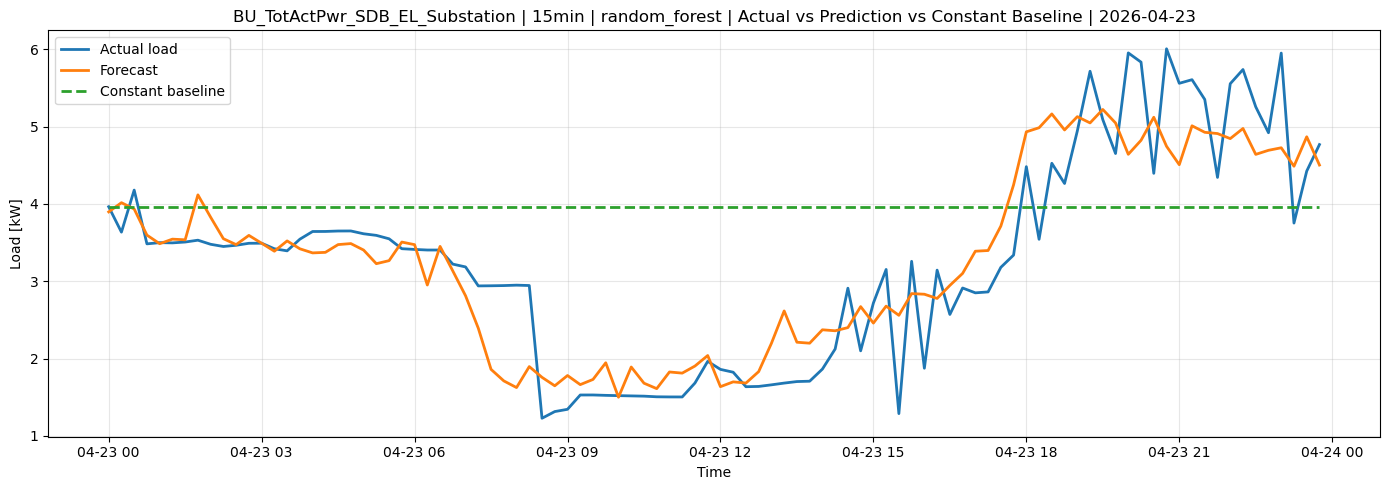

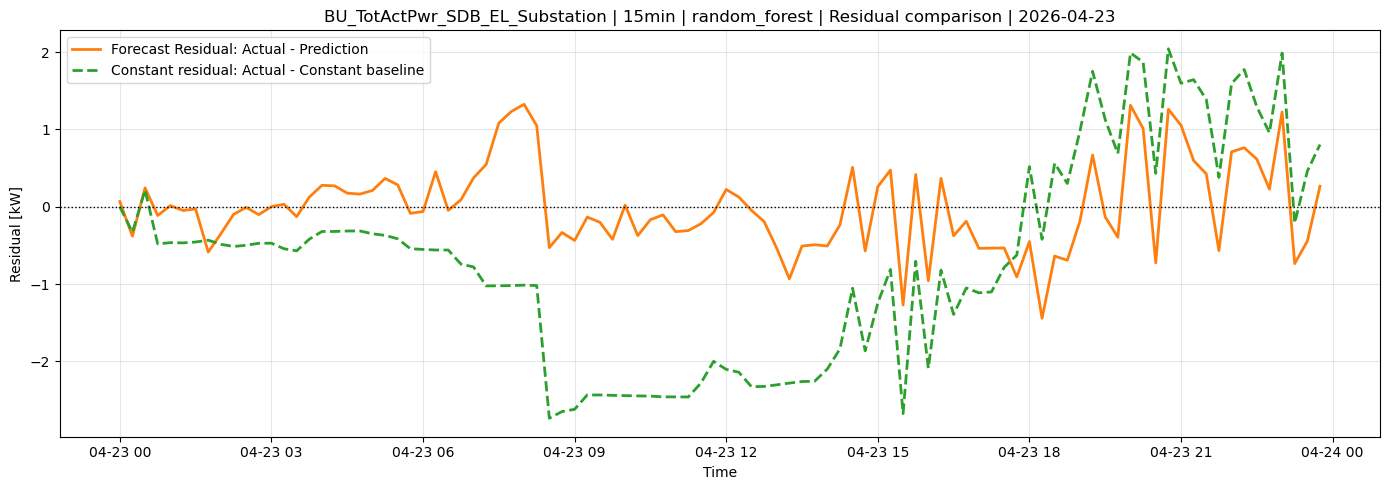

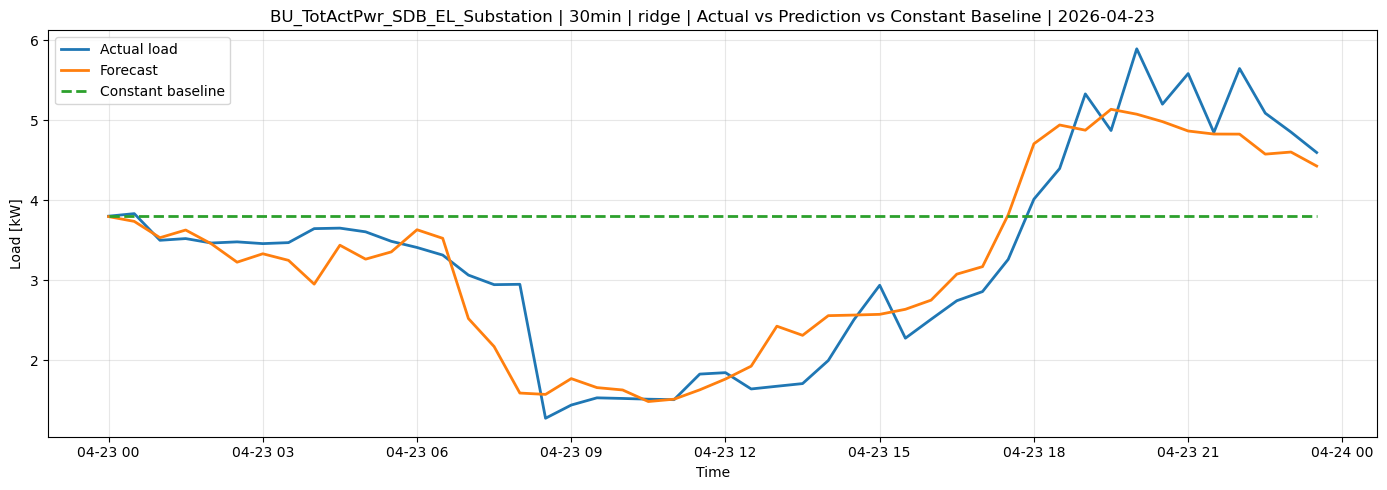

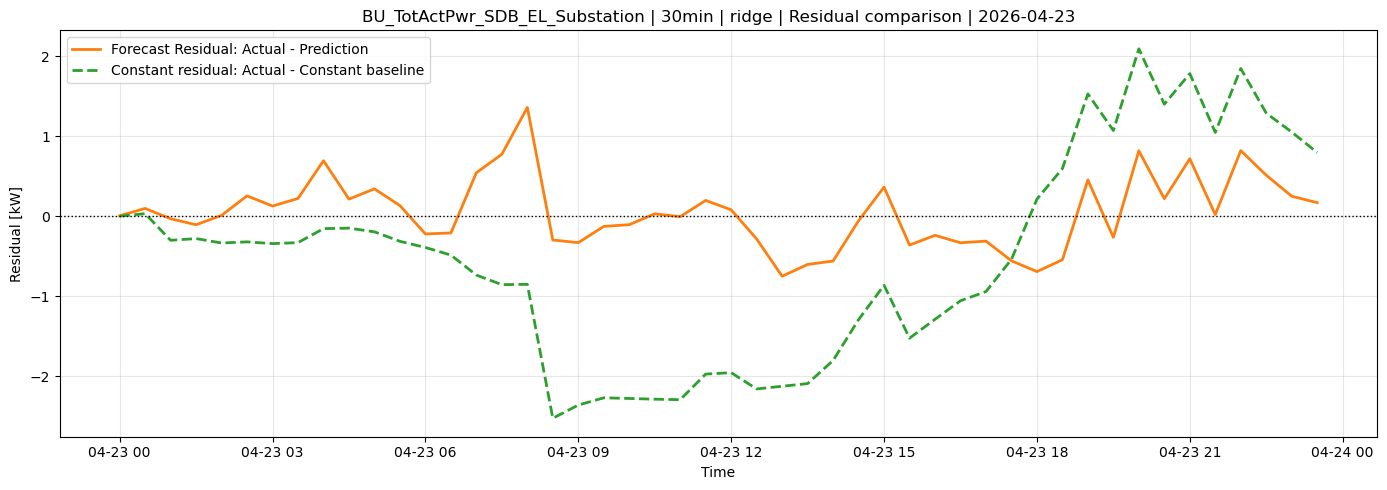

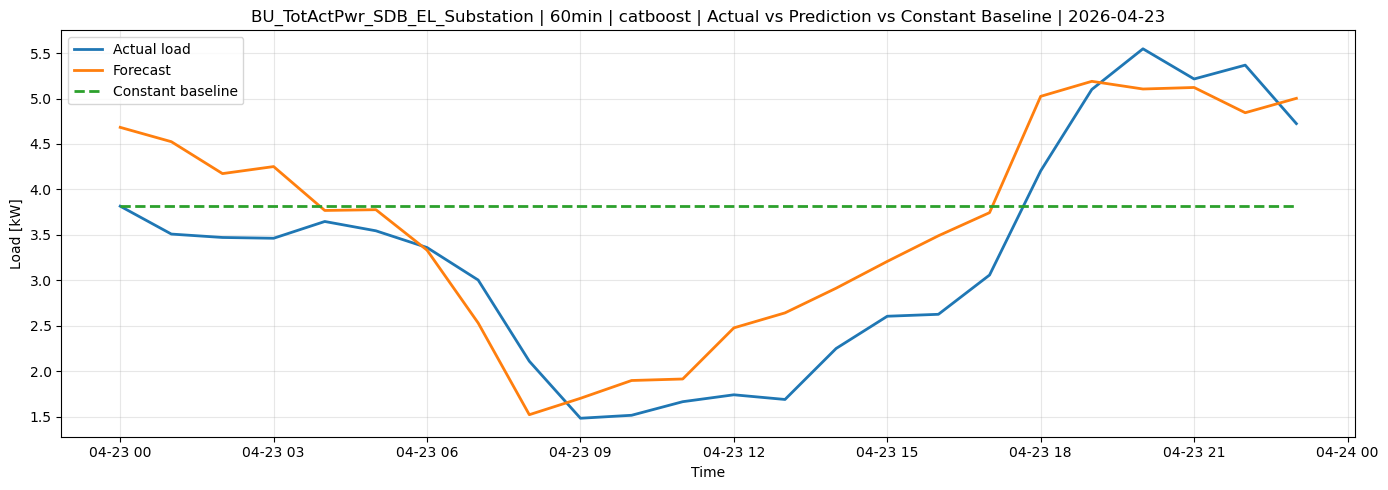

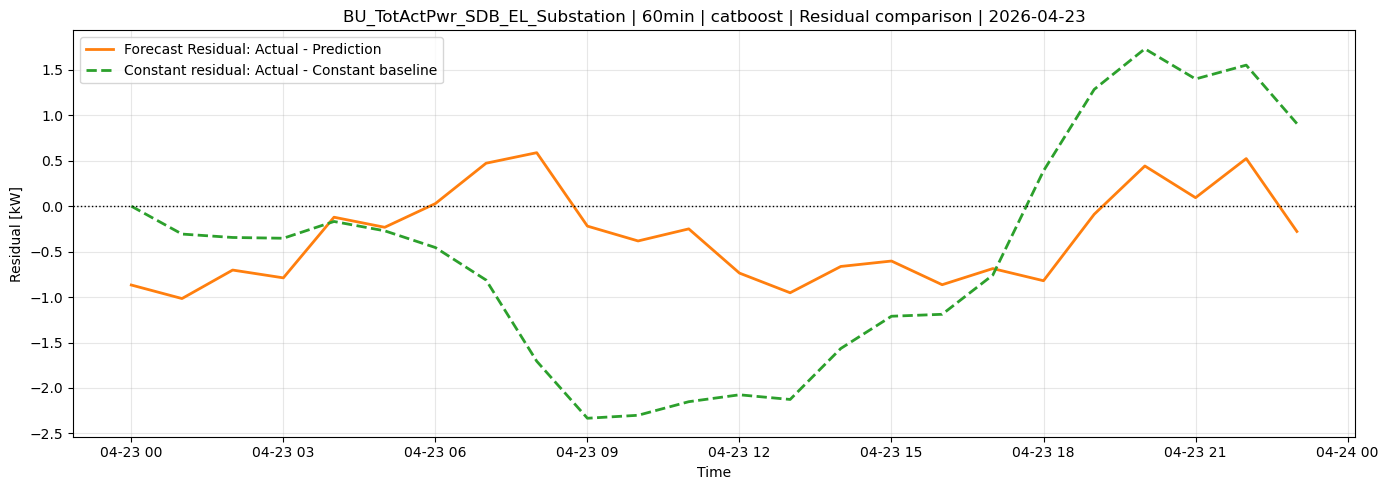

In [23]:
for _, best_row in best_each_resolution.iterrows():
    plot_forecast_and_residuals(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date="2026-04-23"
    )

### Select best ML model for each resolution during common dates

In [24]:
best_model_each_resolution_common = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values(["resolution", "mean_ml_absolute_energy_error_kWh"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_model_each_resolution_common)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,9,81.565080,85.681771,109.140480,-4.116691,-27.575400,14.728917,18.065516,36.265066,44.529342,21.536148,57.470873,-0.171529,-1.148975
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,16.614048,34.278122,41.859627,20.753485,57.511177,-0.200604,-1.091082
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.138770,-0.179620,-0.952218


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def sort_horizon_columns(cols):
    def horizon_number(col):
        base = col.replace("_true", "").replace("_pred", "")
        nums = [p for p in base.split("_") if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)


def get_dt_hours_from_resolution(resolution):
    if resolution == "15min":
        return 0.25
    if resolution == "30min":
        return 0.5
    if resolution == "60min":
        return 1.0
    raise ValueError(f"Unknown resolution: {resolution}")


def plot_common_day_best_resolution(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]

    resolution = best_row["resolution"]
    model_name = best_row["model_name"]
    dt_hours = get_dt_hours_from_resolution(resolution)

    load_name = best_row.get("target_col", target_col)

    df = pd.read_csv(file_path)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()

    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} | {resolution} | {model_name}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    valid = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[valid]
    y_pred = y_pred[valid]
    y_constant = y_constant[valid]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # ==============================
    # Plot 1: Actual vs ML vs Constant
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Actual vs ML Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==============================
    # Plot 2: Residuals
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="ML residual: Actual - ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Plotting common forecast date: 2026-04-22


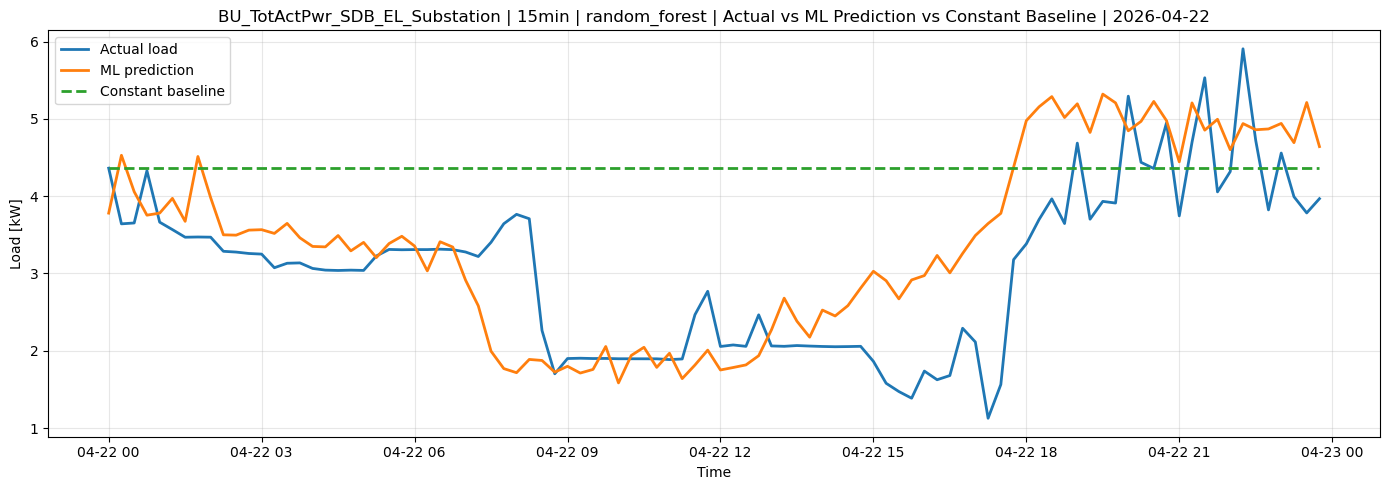

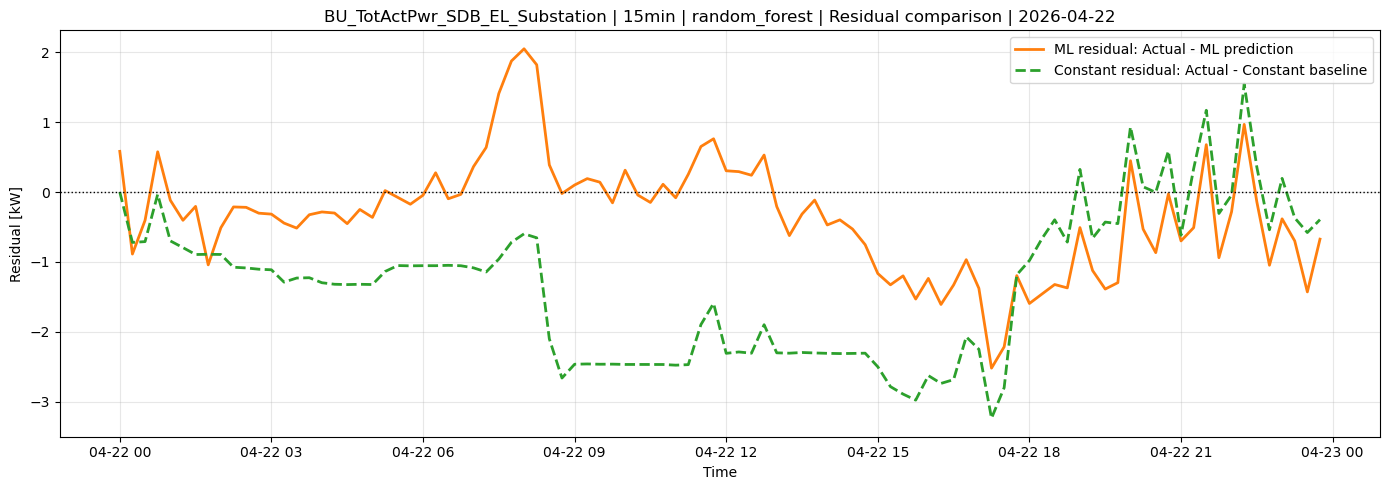

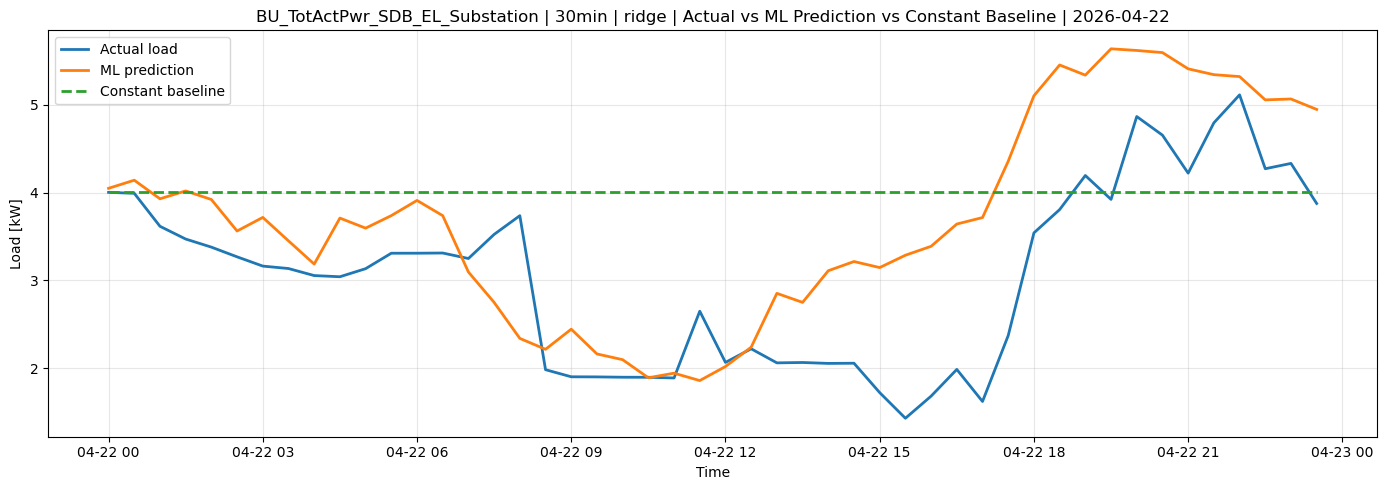

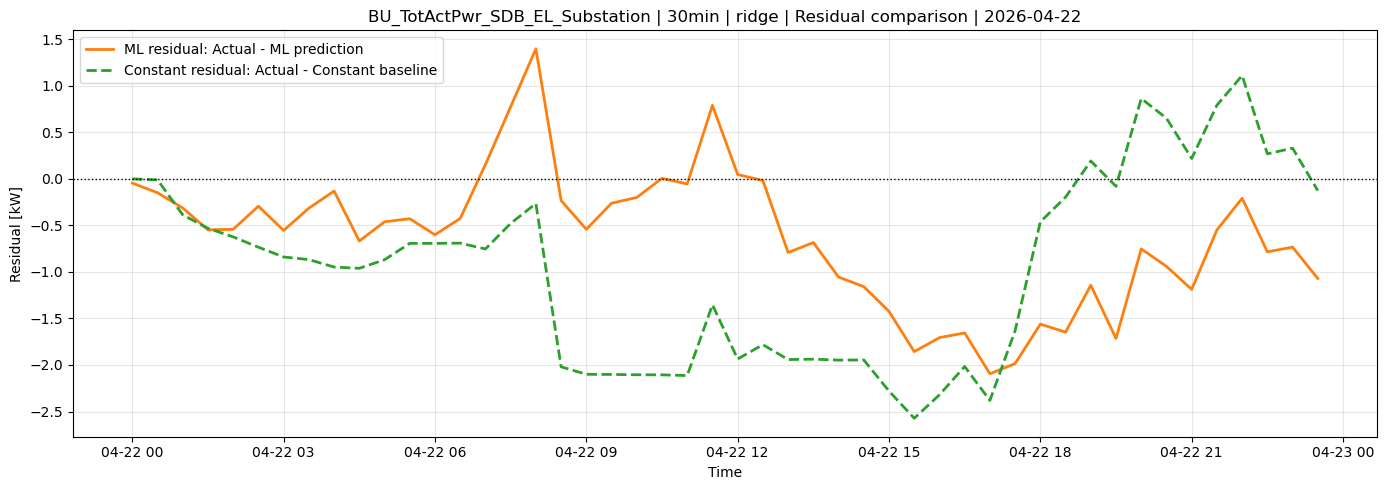

No forecast found for 2026-04-22 | 60min | catboost


In [26]:
plot_date = common_dates[0]

print("Plotting common forecast date:", plot_date)

for _, best_row in best_model_each_resolution_common.iterrows():
    plot_common_day_best_resolution(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date=plot_date
    )

In [27]:
final_common_resolution_comparison = best_model_each_resolution_common[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "mean_constant_residual_kW",

        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_common_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW,file_name
2,60min,catboost,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.138770,-0.179620,-0.952218,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
1,30min,ridge,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,16.614048,34.278122,41.859627,20.753485,57.511177,-0.200604,-1.091082,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
0,15min,random_forest,9,81.565080,85.681771,109.140480,-4.116691,-27.575400,14.728917,18.065516,36.265066,44.529342,21.536148,57.470873,-0.171529,-1.148975,run_20260528_115442_63c0a563_random_forest_BU_...


In [28]:
import matplotlib.pyplot as plt
import numpy as np


# Final summary table for plotting
energy_bar_summary = best_model_each_resolution_common.copy()

energy_bar_summary = energy_bar_summary.sort_values("resolution")

display(energy_bar_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_ml_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_kWh",
        "mean_ml_improvement_vs_constant_percent",
    ]
])


,resolution,model_name,n_common_days,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_improvement_vs_constant_percent
0,15min,random_forest,9,14.728917,36.265066,57.470873
1,30min,ridge,9,13.524637,34.278122,57.511177
2,60min,catboost,8,10.635919,30.822427,65.138770


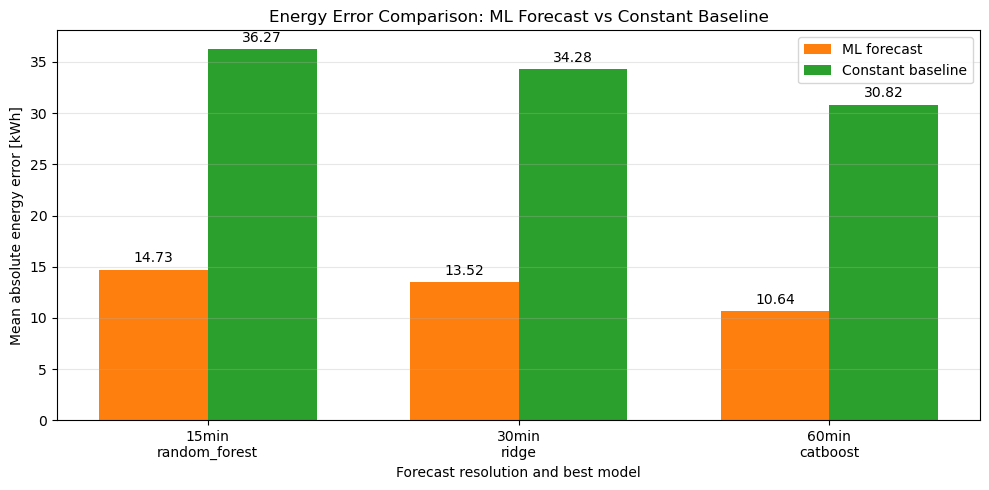

In [29]:
def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)


x = np.arange(len(energy_bar_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    energy_bar_summary["mean_ml_absolute_energy_error_kWh"],
    width,
    label="ML forecast",
    color="tab:orange"
)

ax.bar(
    x + width / 2,
    energy_bar_summary["mean_constant_absolute_energy_error_kWh"],
    width,
    label="Constant baseline",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_bar_summary["resolution"] + "\n" + energy_bar_summary["model_name"]
)

ax.set_ylabel("Mean absolute energy error [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Energy Error Comparison: ML Forecast vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh
0,15min,random_forest,9,81.565080,85.681771,109.140480
1,30min,ridge,9,81.652248,86.466756,107.838213
2,60min,catboost,8,82.711270,87.022158,105.564510


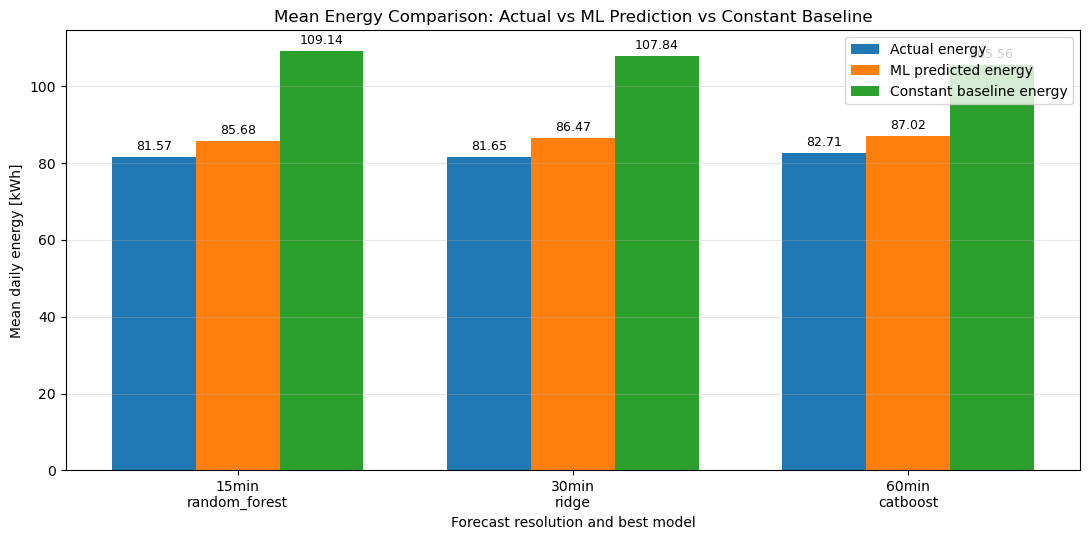

In [30]:
import numpy as np
import matplotlib.pyplot as plt


# Use the best model for each resolution on common forecast dates
energy_total_summary = best_model_each_resolution_common.copy()

# Optional: order resolutions correctly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
energy_total_summary["resolution_order"] = energy_total_summary["resolution"].map(resolution_order)
energy_total_summary = energy_total_summary.sort_values("resolution_order").reset_index(drop=True)

display(energy_total_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",
    ]
])


def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


x = np.arange(len(energy_total_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    energy_total_summary["mean_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    energy_total_summary["mean_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    energy_total_summary["mean_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_total_summary["resolution"] + "\n" + energy_total_summary["model_name"]
)

ax.set_ylabel("Mean daily energy [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Mean Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

### total energy over all common days

,resolution,model_name,file_name,n_common_days,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,resolution_order
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,9,734.085717,771.135938,982.26432,0
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,9,734.870235,778.200803,970.54392,1
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,661.690160,696.177267,844.51608,2


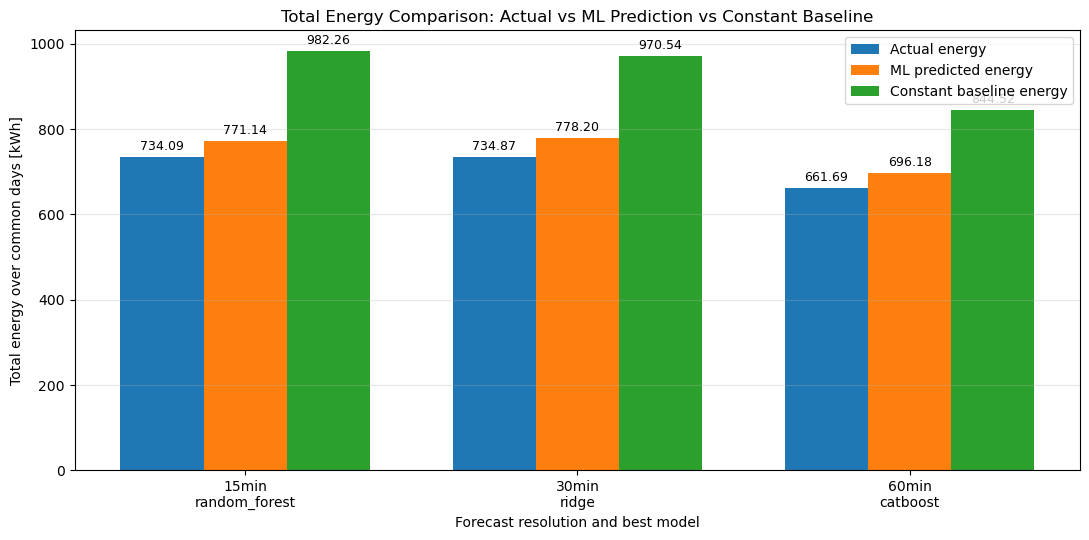

In [31]:
total_energy_summary = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),
        total_actual_energy_kWh=("actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("constant_energy_kWh", "sum"),
    )
)

# Keep only the best files selected earlier
total_energy_summary = total_energy_summary.merge(
    best_model_each_resolution_common[["resolution", "model_name", "file_name"]],
    on=["resolution", "model_name", "file_name"],
    how="inner"
)

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
total_energy_summary["resolution_order"] = total_energy_summary["resolution"].map(resolution_order)
total_energy_summary = total_energy_summary.sort_values("resolution_order").reset_index(drop=True)

display(total_energy_summary)


x = np.arange(len(total_energy_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    total_energy_summary["total_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    total_energy_summary["total_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    total_energy_summary["total_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    total_energy_summary["resolution"] + "\n" + total_energy_summary["model_name"]
)

ax.set_ylabel("Total energy over common days [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Total Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

In [32]:
from pathlib import Path
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_Tech_Room"


# ============================================================
# FUNCTION TO EXTRACT RUN ID FROM FILE NAME
# ============================================================

def extract_run_id(file_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    run_id:
    run_20260521_105037_ca9fc1b2
    """
    parts = file_name.split("_")
    return "_".join(parts[:4])


# ============================================================
# CLEAN ERROR SUMMARY
# ============================================================

error_summary_clean = error_summary.copy()

# Remove invalid/unknown rows
error_summary_clean = error_summary_clean[
    error_summary_clean["resolution"].isin(["15min", "30min", "60min"])
].copy()

error_summary_clean = error_summary_clean[
    error_summary_clean["model_name"] != "unknown"
].copy()

# Add run id and full prediction path
error_summary_clean["run_id"] = error_summary_clean["file_name"].apply(extract_run_id)
error_summary_clean["prediction_path"] = error_summary_clean["file_name"].apply(
    lambda x: str(pred_dir / x)
)


# ============================================================
# BEST MODEL PER RESOLUTION BASED ON LOWEST MAE
# ============================================================

best_model_each_resolution = (
    error_summary_clean
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

# Optional: order resolution properly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
best_model_each_resolution["resolution_order"] = (
    best_model_each_resolution["resolution"].map(resolution_order)
)

best_model_each_resolution = (
    best_model_each_resolution
    .sort_values("resolution_order")
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)


# ============================================================
# FINAL TABLE TO DISPLAY
# ============================================================

best_model_paths_table = best_model_each_resolution[
    [
        "resolution",
        "model_name",
        "run_id",
        "target_col",
        "first_forecast_date",
        "last_forecast_date",
        "n_forecast_days",
        "n_issue_times",
        "n_horizon_steps",
        "MAE",
        "RMSE",
        "MAPE_%",
        "R2",
        "bias_actual_minus_pred",
        "error_std",
        "file_name",
        "prediction_path",
    ]
].copy()

display(best_model_paths_table)

,resolution,model_name,run_id,target_col,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std,file_name,prediction_path
0,15min,random_forest,run_20260528_115442_63c0a563,BU_TotActPwr_SDB_EL_Substation,2026-04-21,2026-04-30,10,10,96,0.620521,0.790645,21.490573,0.634994,-0.141946,0.777799,run_20260528_115442_63c0a563_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,ridge,run_20260527_085838_bddbf081,BU_TotActPwr_SDB_EL_Substation,2026-04-22,2026-04-30,9,9,48,0.563527,0.737966,19.725482,0.670000,-0.200604,0.710177,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,catboost,run_20260513_095636_ab78adf8,BU_TotActPwr_SDB_EL_Substation,2026-04-23,2026-04-30,8,8,24,0.443163,0.560371,15.624057,0.807232,-0.179620,0.530803,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [33]:
best_energy_model_paths_table = best_model_each_resolution_common.copy()

best_energy_model_paths_table["run_id"] = best_energy_model_paths_table["file_name"].apply(extract_run_id)
best_energy_model_paths_table["prediction_path"] = best_energy_model_paths_table["file_name"].apply(
    lambda x: str(pred_dir / x)
)

best_energy_model_paths_table = best_energy_model_paths_table[
    [
        "resolution",
        "model_name",
        "run_id",
        "n_common_days",
        "prediction_path",
    ]
]

display(best_energy_model_paths_table)

,resolution,model_name,run_id,n_common_days,prediction_path
0,15min,random_forest,run_20260528_115442_63c0a563,9,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,ridge,run_20260527_085838_bddbf081,9,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,catboost,run_20260513_095636_ab78adf8,8,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [34]:
from pathlib import Path

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")

best_prediction_paths = [
    str(pred_dir / file_name)
    for file_name in best_model_each_resolution_common["file_name"]
]

for path in best_prediction_paths:
    print(path)

C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_085838_bddbf081_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260513_095636_ab78adf8_catboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv


In [36]:
from pathlib import Path
import pandas as pd
from datetime import datetime


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
registry_path = pred_dir.parent / "best_prediction_files_registry.csv"


def extract_run_id(file_name):
    parts = file_name.split("_")
    return "_".join(parts[:4])


def extract_target_col_from_file_name(file_name, model_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    Returns:
    BU_TotActPwr_Tech_Room
    """

    name = file_name.replace("_profile_predictions.csv", "")

    run_id = extract_run_id(file_name)

    # Remove run_id part
    remaining = name.replace(run_id + "_", "")

    # Remove model name part
    remaining = remaining.replace(model_name + "_", "", 1)

    return remaining


current_best_paths = best_model_each_resolution_common.copy()

current_best_paths["run_id"] = current_best_paths["file_name"].apply(extract_run_id)

current_best_paths["target_col"] = current_best_paths.apply(
    lambda row: extract_target_col_from_file_name(
        row["file_name"],
        row["model_name"]
    ),
    axis=1
)

current_best_paths["prediction_path"] = current_best_paths["file_name"].apply(
    lambda x: str(pred_dir / x)
)

current_best_paths["registry_added_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


wanted_cols = [
    "registry_added_at",
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
    "n_common_days",
    "mean_actual_energy_kWh",
    "mean_ml_predicted_energy_kWh",
    "mean_constant_energy_kWh",
    "mean_ml_absolute_energy_error_kWh",
    "mean_ml_absolute_energy_error_percent",
    "mean_constant_absolute_energy_error_kWh",
    "mean_constant_absolute_energy_error_percent",
    "mean_ml_improvement_vs_constant_percent",
]

current_best_paths = current_best_paths[
    [c for c in wanted_cols if c in current_best_paths.columns]
].copy()


if registry_path.exists():
    registry = pd.read_csv(registry_path)
    registry = pd.concat([registry, current_best_paths], ignore_index=True)
else:
    registry = current_best_paths.copy()


duplicate_key_cols = [
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
]

registry = registry.drop_duplicates(
    subset=[c for c in duplicate_key_cols if c in registry.columns],
    keep="first"
).copy()


resolution_order = {"15min": 0, "30min": 1, "60min": 2}
registry["resolution_order"] = registry["resolution"].map(resolution_order)

registry = (
    registry
    .sort_values(["target_col", "resolution_order", "registry_added_at"])
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)

registry.to_csv(registry_path, index=False)

print("Registry saved/updated:")
print(registry_path)

display(registry)

Registry saved/updated:
C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv


,registry_added_at,target_col,resolution,model_name,run_id,file_name,prediction_path,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_percent
0,2026-05-29 13:43:08,BU_TotActPwr_Academy,15min,xgboost,run_20260512_171555_4d7cc794,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.565797,158.376672,88.996980,29.558080,20.477633,74.282828,43.938212,29.744413
1,2026-05-29 13:43:08,BU_TotActPwr_Academy,30min,random_forest,run_20260526_154855_5f504912,run_20260526_154855_5f504912_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.527170,178.946263,90.357030,38.487983,27.410292,72.994736,43.148351,-3.342269
2,2026-05-29 13:43:08,BU_TotActPwr_Academy,60min,random_forest,run_20260521_093016_89fcbb0f,run_20260521_093016_89fcbb0f_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.515481,164.015870,88.651500,34.576039,25.591586,73.225176,43.307650,-2.266626
3,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260528_115442_63c0a563,run_20260528_115442_63c0a563_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,81.565080,85.681771,109.140480,14.728917,18.065516,36.265066,44.529342,57.470873
4,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,30min,ridge,run_20260527_085838_bddbf081,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,81.652248,86.466756,107.838213,13.524637,16.614048,34.278122,41.859627,57.511177
5,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,60min,catboost,run_20260513_095636_ab78adf8,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,82.711270,87.022158,105.564510,10.635919,12.836926,30.822427,37.315588,65.138770
6,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,15min,random_forest,run_20260521_105037_ca9fc1b2,run_20260521_105037_ca9fc1b2_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.106232,55.353108,90.743120,7.459176,12.808193,33.294782,57.338506,77.390772
7,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,30min,random_forest,run_20260527_102550_662ba0ff,run_20260527_102550_662ba0ff_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.080091,55.520197,90.757307,6.898038,11.853753,33.223860,57.248999,79.056137
8,2026-05-29 13:43:18,BU_TotActPwr_Tech_Room,60min,xgboost,run_20260513_094936_b3ae2d0e,run_20260513_094936_b3ae2d0e_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,58.073656,54.791928,90.179760,6.563000,11.283821,32.685582,56.331646,79.770657
